In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from lokan import *
from lokan import loKAN

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# **Dataset** $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ and 2 learnable prod group

In [3]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
  
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

In [4]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, batch_size=512, epochs=1000):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    def relative_mse_loss(y_pred, y_true, epsilon=1e-8):
        # (batch_size, out_dim)
        squared_diff = (y_pred - y_true)**2
        # Нормализуем на квадрат истинного значения
        relative_diff = squared_diff / (y_true**2 + epsilon)
        return torch.mean(relative_diff)

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-6  # для L1 активаций 1.
    lamb_ent_acts = 1e-3  # для энтропии активаций 2.

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
                    
            new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            # train_loss = relative_mse_loss(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=1.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            # loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            # test_loss = relative_mse_loss(test_outputs, dataset['test_label'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')
            # for module in model.modules():
            #     if isinstance(module, NexusKANLayer):
            #         probs = torch.softmax(module.logits / module.tau, dim=-1)
            #         rounded_probs = probs.round(decimals=3)
            #         print(rounded_probs)
        

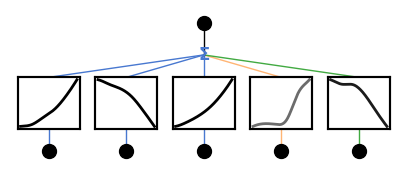

In [5]:
model = loKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [6]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

Epoch [10/100], Train Loss: 0.2240, Test Loss: 0.2894
Epoch [20/100], Train Loss: 0.0015, Test Loss: 0.0016
Epoch [30/100], Train Loss: 0.0008, Test Loss: 0.0008
Epoch [40/100], Train Loss: 0.0007, Test Loss: 0.0007
Epoch [50/100], Train Loss: 0.0007, Test Loss: 0.0007
Epoch [60/100], Train Loss: 0.0007, Test Loss: 0.0006
Epoch [70/100], Train Loss: 0.0007, Test Loss: 0.0006
Epoch [80/100], Train Loss: 0.0007, Test Loss: 0.0006
Epoch [90/100], Train Loss: 0.0007, Test Loss: 0.0006
Epoch [100/100], Train Loss: 0.0007, Test Loss: 0.0006


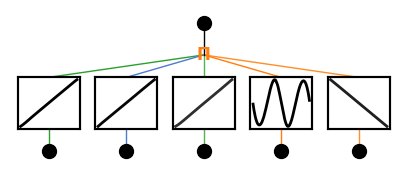

In [7]:
model.plot()

In [8]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[-2.4846e+00, -2.0599e+00, -1.0424e+00, -3.1194e-01,  3.2616e-01,
           7.6422e-01,  1.1369e+00,  1.0448e+00]],

        [[-2.4647e+00, -1.4749e+00, -8.2809e-01, -2.1363e-01,  2.2870e-01,
           5.8072e-01,  7.9329e-01,  8.6688e-01]],

        [[-1.6021e+00, -1.3528e+00, -5.7518e-01, -9.1284e-02,  1.2976e-01,
           1.5107e-02, -1.8788e-01, -9.6481e-01]],

        [[ 5.8701e+00, -1.0954e+00, -9.5662e-01,  2.0674e+00, -2.0673e+00,
           9.5303e-01,  1.1179e+00, -6.1258e+00]],

        [[ 1.2066e+00,  6.0655e-01,  1.9942e-01, -2.8081e-02,  4.9564e-03,
           2.5742e-01,  7.6246e-01,  1.2761e+00]]], device='cuda:0')
act_fun.0.scale_base tensor([[ 1.4589],
        [ 0.8260],
        [ 0.8212],
        [ 0.0455],
        [-1.2851]], device='cuda:0')
act_fun.0.scale_sp tensor([[0.7550],
        [0.5127],
        [0.2342],
        [1.8554],
        [0.4200]], device='cuda:0')
act_fun.0.logits tensor([[[-1.2536,  6.1745, -1.4381]],

        [[-1.70

In [9]:
for module in model.modules():
    if isinstance(module, LOKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1., 0.]],

        [[0., 0., 1.]],

        [[0., 1., 0.]],

        [[1., 0., 0.]],

        [[1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)


# **Dataset** $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$ 

## LBFGS

In [ ]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, epochs=1000, 
                    logits_requires_grad=True, splines_requires_grad=True,
                    use_full_batch=True, batch_size=512):
    """
    Обучение модели с оптимизатором LBFGS.
    
    Args:
        use_full_batch: если True — используется весь датасет за шаг (рекомендуется для LBFGS)
                        если False — эмуляция mini-batch (менее стабильно)
    """
    # Инициализация LBFGS
    optimizer = optim.LBFGS(model.parameters(), 
                           lr=lr, 
                           history_size=10, 
                           line_search_fn="strong_wolfe", 
                           tolerance_grad=1e-32, 
                           tolerance_change=1e-32)
    criterion = nn.MSELoss()
    
    lamb_l1_acts = 1e-3
    lamb_ent_acts = 1e-3

    for epoch in range(epochs):
        # === Обновление гиперпараметров (раз в эпоху, не внутри closure!) ===
        current_lr = lr
        # current_lr = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
        new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
        
        # Обновление requires_grad и tau для слоёв модели
        for module in model.modules():
            if isinstance(module, LOKANLayer):
                module.logits.requires_grad = logits_requires_grad
                module.scale_base.requires_grad = splines_requires_grad
                module.scale_sp.requires_grad = splines_requires_grad
                module.coef.requires_grad = splines_requires_grad
                module.tau = new_tau
        
        # Обновление learning rate в оптимизаторе
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr
        
        # === Функция closure для LBFGS ===
        def closure():
            optimizer.zero_grad()
            
            if use_full_batch:
                # Полный датасет (рекомендуется)
                batch_x = dataset['train_input']
                batch_y = dataset['train_label']
            else:
                # Эмуляция mini-batch (не рекомендуется для LBFGS)
                idx = torch.randperm(dataset['train_input'].shape[0])[:batch_size]
                batch_x = dataset['train_input'][idx]
                batch_y = dataset['train_label'][idx]
            
            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            # lamb_ent_ops = 10.0
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=10.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # === Регуляризация активаций (L1 + энтропия) ===
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            # loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            loss.backward()
            return loss
        
        # === Шаг оптимизации ===
        optimizer.step(closure)
        
        # === Оценка на тесте ===
        with torch.no_grad():
            train_out = model(dataset['train_input'])
            train_loss = criterion(train_out, dataset['train_label'])
            test_out = model(dataset['test_input'])
            test_loss = criterion(test_out, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'--- Epoch [{epoch+1}/{epochs}], '
                  f'Train Loss: {train_loss.item():.4f}, '
                  f'Test Loss: {test_loss.item():.4f}')

## Adam

In [10]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_tau_osc(step, total_steps, tau_start=2.0, tau_sup=1.0, tau_end=0.1, freq=7.0):
    top_th = tau_start * (tau_end / tau_start) ** (step / total_steps)
    bottom_th = tau_sup * (tau_end / tau_sup) ** (step / total_steps)
    osc = (top_th + bottom_th) + (top_th - bottom_th) * np.cos(freq * torch.pi * step / total_steps)
    return osc / 2

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

# def get_lamb_osc(step, total_steps, tau_start=2.0, tau_sup=1.0, tau_end=0.1, freq=3.0):
#     top_th = tau_start * (tau_end / tau_start) ** (step / total_steps)
#     bottom_th = tau_sup * (tau_end / tau_sup) ** (step / total_steps)
#     osc = (top_th + bottom_th) - (top_th - bottom_th) * np.cos(freq * torch.pi * step / total_steps)
#     return osc / 2

def fit_model(model, dataset, lr=0.1, batch_size=64, epochs=100, logits_requires_grad=True, splines_requires_grad=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    def relative_mse_loss(y_pred, y_true, epsilon=1e-8):
        # (batch_size, out_dim)
        squared_diff = (y_pred - y_true)**2
        # Нормализуем на квадрат истинного значения
        relative_diff = squared_diff / (y_true**2 + epsilon)
        return torch.mean(relative_diff)
        

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-3  # для L1 активаций 1.
    lamb_ent_acts = 1e-3  # для энтропии активаций 2.

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
            
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    module.logits.requires_grad = logits_requires_grad
                    
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    module.scale_base.requires_grad = splines_requires_grad
                    module.scale_sp.requires_grad = splines_requires_grad
                    module.coef.requires_grad = splines_requires_grad
                   
            # new_tau = 2.0 
            new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            # train_loss = criterion(outputs, batch_y)
            train_loss = relative_mse_loss(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            # lamb_ent_ops = 10.0
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=10.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, LOKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            # loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            test_loss = relative_mse_loss(test_outputs, dataset['test_label'])
            # test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'--- Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')
            # for module in model.modules():
            #     if isinstance(module, LOKANLayer):
            #         probs = torch.softmax(module.logits / module.tau, dim=-1)
            #         rounded_probs = probs.round(decimals=3)
            #         print("tau: ", module.tau)
            #         print(rounded_probs)

## **Test 0:** $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ (don`t work with relative MSE)

In [12]:
end_range = 1.0
start_range = 0.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
  
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

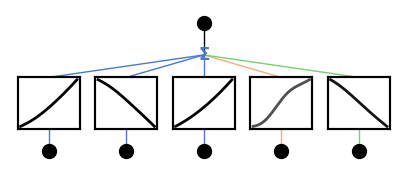

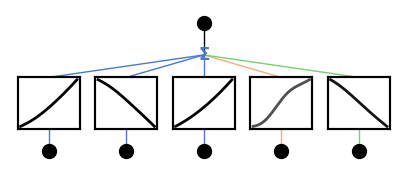

In [13]:
model = loKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [14]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 1.0978, Test Loss: 1.2999
--- Epoch [20/100], Train Loss: 1.0435, Test Loss: 1.0924
--- Epoch [30/100], Train Loss: 1.0096, Test Loss: 1.0149
--- Epoch [40/100], Train Loss: 0.9927, Test Loss: 0.9885
--- Epoch [50/100], Train Loss: 0.9880, Test Loss: 0.9830
--- Epoch [60/100], Train Loss: 0.9878, Test Loss: 0.9841
--- Epoch [70/100], Train Loss: 0.9875, Test Loss: 0.9901
--- Epoch [80/100], Train Loss: 0.9878, Test Loss: 1.0039
--- Epoch [90/100], Train Loss: 0.9968, Test Loss: 1.0120
--- Epoch [100/100], Train Loss: 1.0053, Test Loss: 1.0165


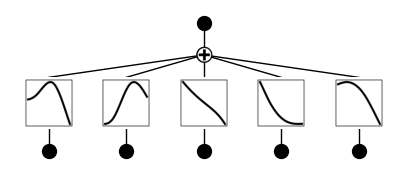

In [7]:
model.plot()

In [8]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[1.0000, 0.0000, 0.0000]],

        [[0.9980, 0.0020, 0.0000]],

        [[0.0000, 1.0000, 0.0000]],

        [[1.0000, 0.0000, 0.0000]],

        [[0.0000, 1.0000, 0.0000]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 1 :** $y = \frac{x_0}{x_1} + \frac{x_2}{x_3}$

In [11]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

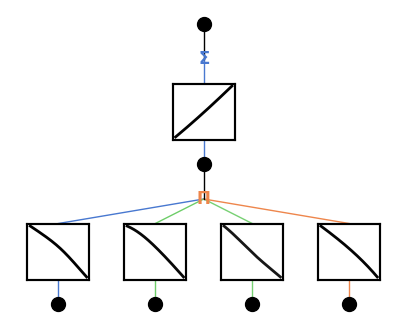

In [12]:
model = loKAN(width=[4, 1, 1], grid=5, k=3, seed=42, 
                #  grid_range=[0.5, 4.0], 
                 device=device)
model(dataset['train_input'])
model.plot()

In [13]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.0184, Test Loss: 0.0250
--- Epoch [20/100], Train Loss: 0.0034, Test Loss: 0.0041
--- Epoch [30/100], Train Loss: 0.0017, Test Loss: 0.0025
--- Epoch [40/100], Train Loss: 0.0015, Test Loss: 0.0019
--- Epoch [50/100], Train Loss: 0.0015, Test Loss: 0.0017
--- Epoch [60/100], Train Loss: 0.0014, Test Loss: 0.0017
--- Epoch [70/100], Train Loss: 0.0013, Test Loss: 0.0016
--- Epoch [80/100], Train Loss: 0.0013, Test Loss: 0.0016
--- Epoch [90/100], Train Loss: 0.0013, Test Loss: 0.0015
--- Epoch [100/100], Train Loss: 0.0012, Test Loss: 0.0015


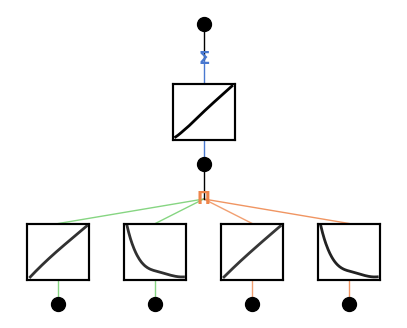

In [14]:
model.plot()

In [19]:
for module in model.modules():
    if isinstance(module, LOKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1., 0.]],

        [[0., 1., 0.]],

        [[1., 0., 0.]],

        [[1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


## **Test 2 :** $y = \frac{x_0}{x_1}$

In [15]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 2) + start_range
# x[:, 1] = 0.5

y = x[:, 0] / x[:, 1]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

In [16]:
model = loKAN(width=[2, 1, 1], grid=5, k=3, seed=42, 
                #  grid_range=[0.5, 4.0], 
                 device=device)

In [17]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.0044, Test Loss: 0.0038
--- Epoch [20/100], Train Loss: 0.0025, Test Loss: 0.0011
--- Epoch [30/100], Train Loss: 0.0016, Test Loss: 0.0009
--- Epoch [40/100], Train Loss: 0.0015, Test Loss: 0.0008
--- Epoch [50/100], Train Loss: 0.0014, Test Loss: 0.0009
--- Epoch [60/100], Train Loss: 0.0020, Test Loss: 0.0007
--- Epoch [70/100], Train Loss: 0.0010, Test Loss: 0.0004
--- Epoch [80/100], Train Loss: 0.0010, Test Loss: 0.0005
--- Epoch [90/100], Train Loss: 0.0008, Test Loss: 0.0007
--- Epoch [100/100], Train Loss: 0.0007, Test Loss: 0.0003


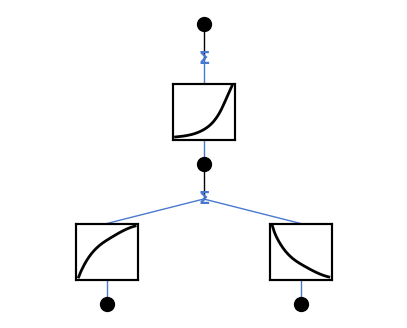

In [18]:
model.plot()

In [19]:
for module in model.modules():
    if isinstance(module, LOKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.2820, 0.7180]],

        [[0.2820, 0.7180]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


In [20]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[ 1.1586e-02,  3.6656e-02, -9.0715e+00, -2.1116e+00, -8.5410e-01,
          -5.6055e-01, -2.7583e-01, -2.6839e-01]],

        [[ 4.0875e-03,  2.7029e-02,  3.3497e+01,  1.4188e+00, -4.7377e-01,
          -5.8954e-01, -5.7724e-01, -6.8467e-02]]], device='cuda:0')
act_fun.0.scale_base tensor([[-0.1187],
        [-0.7089]], device='cuda:0')
act_fun.0.scale_sp tensor([[1.0122],
        [0.6187]], device='cuda:0')
act_fun.0.logits tensor([[[0.5371, 0.6334]],

        [[0.6815, 0.7778]]], device='cuda:0')
act_fun.1.coef tensor([[[0.0353, 0.0826, 0.2527, 0.7615, 2.4695, 1.7160, 0.8757, 0.0116]]],
       device='cuda:0')
act_fun.1.scale_base tensor([[0.1701]], device='cuda:0')
act_fun.1.scale_sp tensor([[3.3232]], device='cuda:0')
act_fun.1.logits tensor([[[0.2695]]], device='cuda:0')
symbolic_fun.0.affine tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.]]], device='cuda:0')
symbolic_fun.1.affine tensor([[[0., 0., 0., 0.]]], device='cuda:0')


## **Test 3 :** $y = \frac{\frac{x_0}{x_1}}{\frac{x_2}{x_3}}$

In [21]:
end_range = 3.0
start_range = 1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] / x[:, 2] / x[:, 3]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

In [22]:
model = loKAN(width=[4, 2, 1], grid=5, k=3, seed=42, grid_range=[0.5, 4.0], device=device)

In [23]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.0015, Test Loss: 0.0021
--- Epoch [20/100], Train Loss: 0.0003, Test Loss: 0.0003
--- Epoch [30/100], Train Loss: 0.0000, Test Loss: 0.0001
--- Epoch [40/100], Train Loss: 0.0003, Test Loss: 0.0004
--- Epoch [50/100], Train Loss: 0.0003, Test Loss: 0.0002
--- Epoch [60/100], Train Loss: 0.0000, Test Loss: 0.0000
--- Epoch [70/100], Train Loss: 0.0000, Test Loss: 0.0000
--- Epoch [80/100], Train Loss: 0.0000, Test Loss: 0.0001
--- Epoch [90/100], Train Loss: 0.0000, Test Loss: 0.0000
--- Epoch [100/100], Train Loss: 0.0000, Test Loss: 0.0001


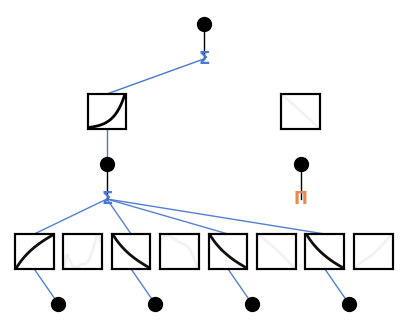

In [24]:
model.plot()

In [25]:
for module in model.modules():
    if isinstance(module, LOKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.3630, 0.1260, 0.5110],
         [0.0160, 0.9840, 0.0000]],

        [[0.0100, 0.0020, 0.9880],
         [0.0020, 0.9980, 0.0000]],

        [[0.0120, 0.0020, 0.9860],
         [0.1610, 0.8390, 0.0000]],

        [[0.0040, 0.0110, 0.9850],
         [0.9500, 0.0500, 0.0010]]], device='cuda:0', grad_fn=<RoundBackward1>)
tensor([[[0.1610, 0.8390]],

        [[0.9010, 0.0990]]], device='cuda:0', grad_fn=<RoundBackward1>)


## $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$

In [20]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 8) + start_range

# x[:, 1] = 5.5
# x[:, 3] = 6.4
# x[:, 5] = 8.5
# x[:, 7] = 7.6

y = (x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]) / (x[:, 4] / x[:, 5] + x[:, 6] / x[:, 7])

dataset = {
    'train_input': x[:num_samples],
    'train_label': y[:num_samples].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 8]), torch.Size([1000, 1]))

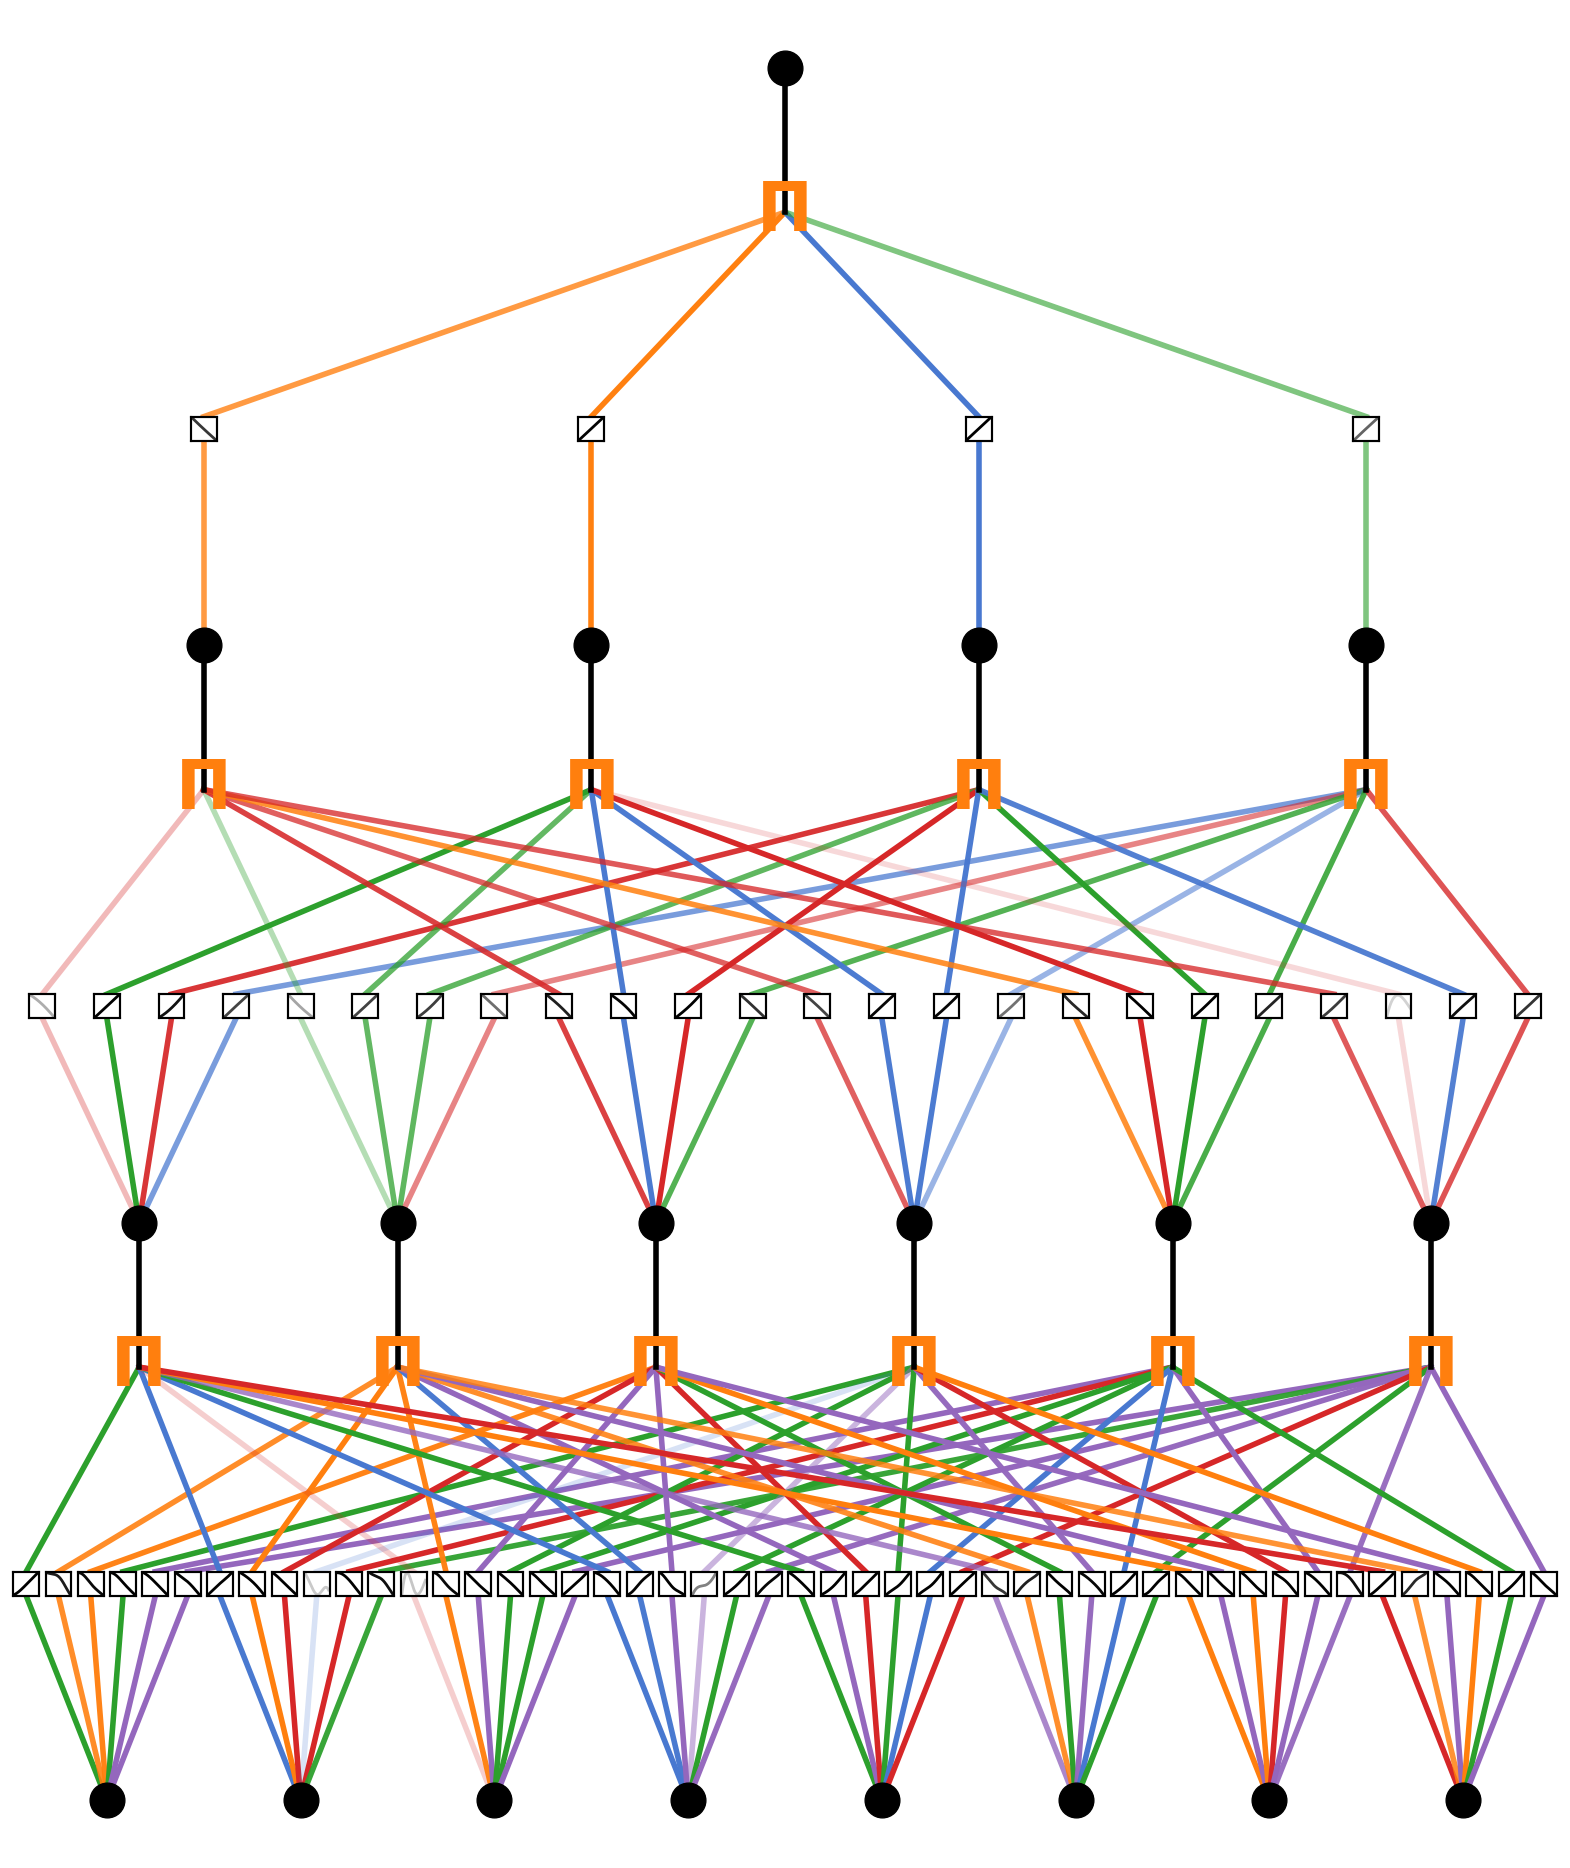

In [21]:
model = loKAN(width=[8, 6, 4, 1], grid=5, k=3, seed=42, 
                #  grid_range=[3.0, 20.0],
                 device=device)
model(dataset['train_input'])
model.plot(scale=2.0)

In [22]:
fit_model(model=model, 
          dataset=dataset,
          lr=0.1, 
          batch_size=32, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.0843, Test Loss: 0.0568
--- Epoch [20/100], Train Loss: 0.0360, Test Loss: 0.0326
--- Epoch [30/100], Train Loss: 0.0321, Test Loss: 0.0319
--- Epoch [40/100], Train Loss: 0.0357, Test Loss: 0.0289
--- Epoch [50/100], Train Loss: 0.0329, Test Loss: 0.0274
--- Epoch [60/100], Train Loss: 0.0299, Test Loss: 0.0305
--- Epoch [70/100], Train Loss: 0.0246, Test Loss: 0.0262
--- Epoch [80/100], Train Loss: 0.0255, Test Loss: 0.0252
--- Epoch [90/100], Train Loss: 0.0243, Test Loss: 0.0240
--- Epoch [100/100], Train Loss: 0.0330, Test Loss: 0.0270


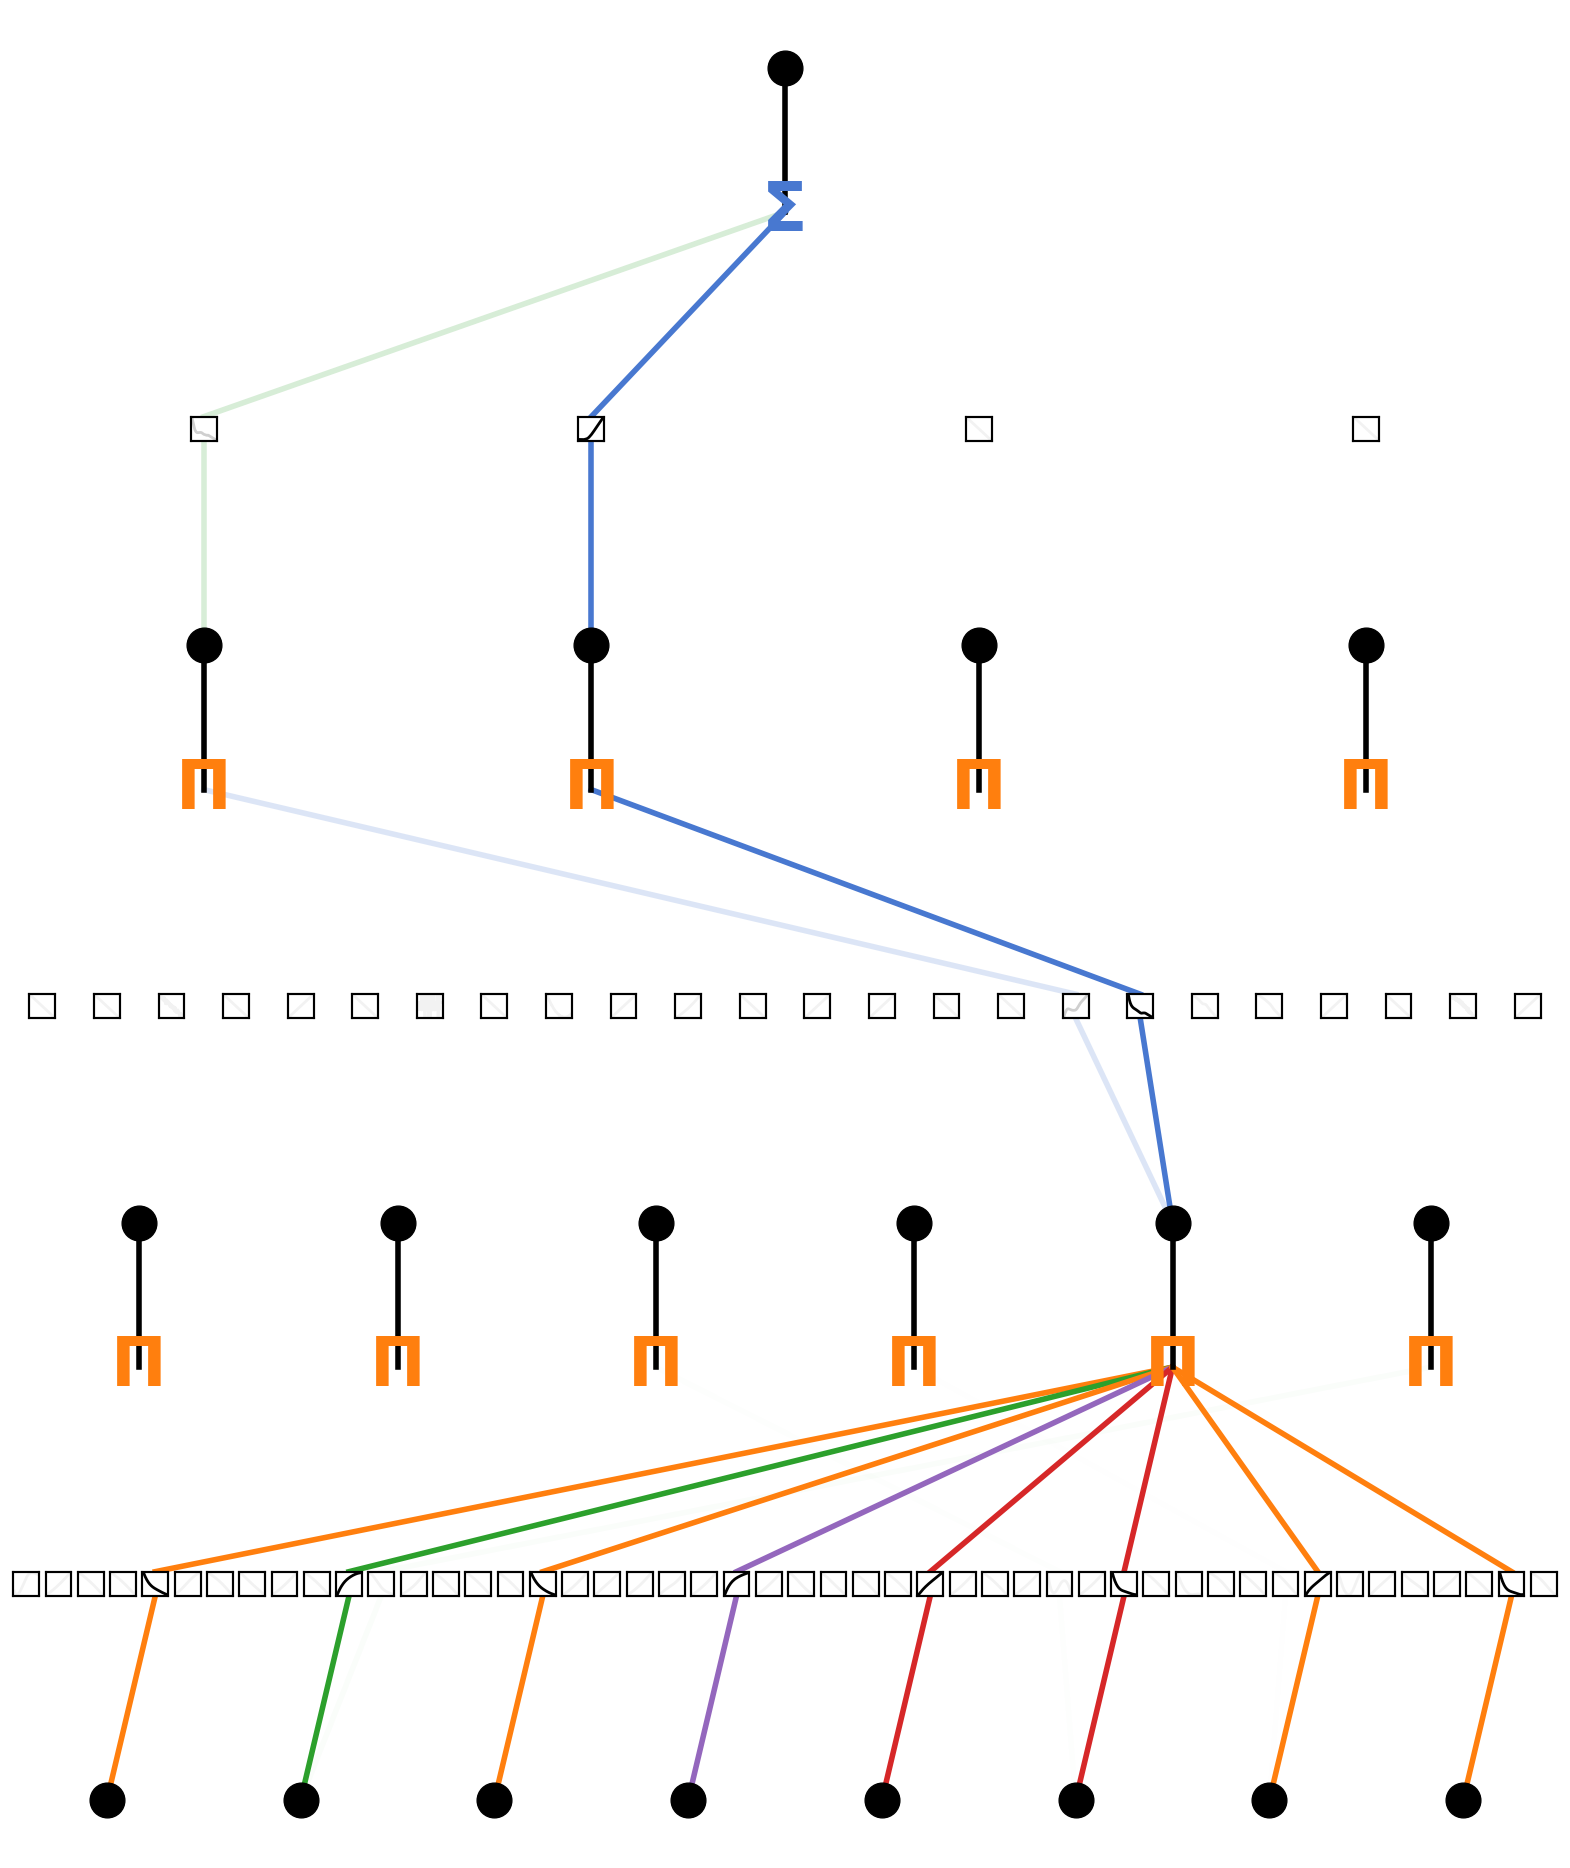

In [23]:
model.plot(scale=2.0)

In [40]:
for module in model.modules():
    if isinstance(module, LOKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0.9470, 0.0150, 0.0010, 0.0370, 0.0000],
         [0.2580, 0.0900, 0.3820, 0.1680, 0.1020],
         [1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0010, 0.0140, 0.9860, 0.0000, 0.0000],
         [0.9400, 0.0000, 0.0000, 0.0500, 0.0100],
         [0.4220, 0.0010, 0.3240, 0.0000, 0.2530]],

        [[0.6540, 0.0400, 0.0000, 0.2540, 0.0510],
         [0.2570, 0.1900, 0.3430, 0.2110, 0.0000],
         [0.0000, 0.3800, 0.6190, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.9920, 0.0070, 0.0000],
         [0.0000, 0.0010, 0.9990, 0.0000, 0.0000],
         [0.0000, 0.3360, 0.2660, 0.3050, 0.0930]],

        [[0.0000, 0.0000, 1.0000, 0.0000, 0.0000],
         [0.3600, 0.3080, 0.0030, 0.3250, 0.0030],
         [0.0000, 0.0000, 0.0000, 1.0000, 0.0000],
         [0.0030, 0.6300, 0.0010, 0.3670, 0.0000],
         [0.6210, 0.0080, 0.3680, 0.0000, 0.0030],
         [0.3880, 0.2770, 0.0000, 0.3340, 0.0010]],

        [[0.1590, 0.0330, 0.0030, 0.6540, 0.1510],
         [0.3000, 0.0430,